In [2]:
# Import pandas
import pandas as pd

In [3]:
# Step 2: Define the file path
file_path = r"E:\suicide\data_1.xlsx"

In [4]:
# Read the Excel file 
df = pd.read_excel(file_path, sheet_name="total")

In [5]:
# Step 4: Preview the first 5 rows
print(df.head())

                 Area                             variable description  \
0  Sub-Saharan Africa  Suicide mortality rate (per 100,000 population)   
1      European Union  Suicide mortality rate (per 100,000 population)   
2          South Asia  Suicide mortality rate (per 100,000 population)   

    UNIT_MEASURE_LABEL       2000       2001       2002       2003       2004  \
0  Per 100 000 persons   6.950379   6.906873   6.931328   6.959222   6.921441   
1  Per 100 000 persons  14.864175  14.541031  14.722899  14.539500  14.177327   
2  Per 100 000 persons  14.951755  14.142524  14.104510  13.964230  14.207303   

        2005       2006  ...       2012       2013       2014       2015  \
0   6.788916   6.823093  ...   6.846694   6.839545   6.866439   6.888396   
1  13.832437  13.370223  ...  13.459967  13.445862  13.014602  12.602672   
2  14.467672  14.616516  ...  14.450099  14.263815  13.770668  13.343239   

        2016       2017       2018       2019       2020       2021  
0  

In [6]:
# Optional: check column names and data types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Area                  3 non-null      object 
 1   variable description  3 non-null      object 
 2   UNIT_MEASURE_LABEL    3 non-null      object 
 3   2000                  3 non-null      float64
 4   2001                  3 non-null      float64
 5   2002                  3 non-null      float64
 6   2003                  3 non-null      float64
 7   2004                  3 non-null      float64
 8   2005                  3 non-null      float64
 9   2006                  3 non-null      float64
 10  2007                  3 non-null      float64
 11  2008                  3 non-null      float64
 12  2009                  3 non-null      float64
 13  2010                  3 non-null      float64
 14  2011                  3 non-null      float64
 15  2012                  3 non

In [7]:
# Convert wide to long format
df_long = pd.melt(
    df,
    id_vars=['Area', 'variable description', 'UNIT_MEASURE_LABEL'],
    var_name='Year',
    value_name='Value'
)

In [8]:
# convert Year to integer
df_long['Year'] = df_long['Year'].astype(int)

# Preview
print(df_long.head())

                 Area                             variable description  \
0  Sub-Saharan Africa  Suicide mortality rate (per 100,000 population)   
1      European Union  Suicide mortality rate (per 100,000 population)   
2          South Asia  Suicide mortality rate (per 100,000 population)   
3  Sub-Saharan Africa  Suicide mortality rate (per 100,000 population)   
4      European Union  Suicide mortality rate (per 100,000 population)   

    UNIT_MEASURE_LABEL  Year      Value  
0  Per 100 000 persons  2000   6.950379  
1  Per 100 000 persons  2000  14.864175  
2  Per 100 000 persons  2000  14.951755  
3  Per 100 000 persons  2001   6.906873  
4  Per 100 000 persons  2001  14.541031  


In [9]:
print(df_long.head())

                 Area                             variable description  \
0  Sub-Saharan Africa  Suicide mortality rate (per 100,000 population)   
1      European Union  Suicide mortality rate (per 100,000 population)   
2          South Asia  Suicide mortality rate (per 100,000 population)   
3  Sub-Saharan Africa  Suicide mortality rate (per 100,000 population)   
4      European Union  Suicide mortality rate (per 100,000 population)   

    UNIT_MEASURE_LABEL  Year      Value  
0  Per 100 000 persons  2000   6.950379  
1  Per 100 000 persons  2000  14.864175  
2  Per 100 000 persons  2000  14.951755  
3  Per 100 000 persons  2001   6.906873  
4  Per 100 000 persons  2001  14.541031  


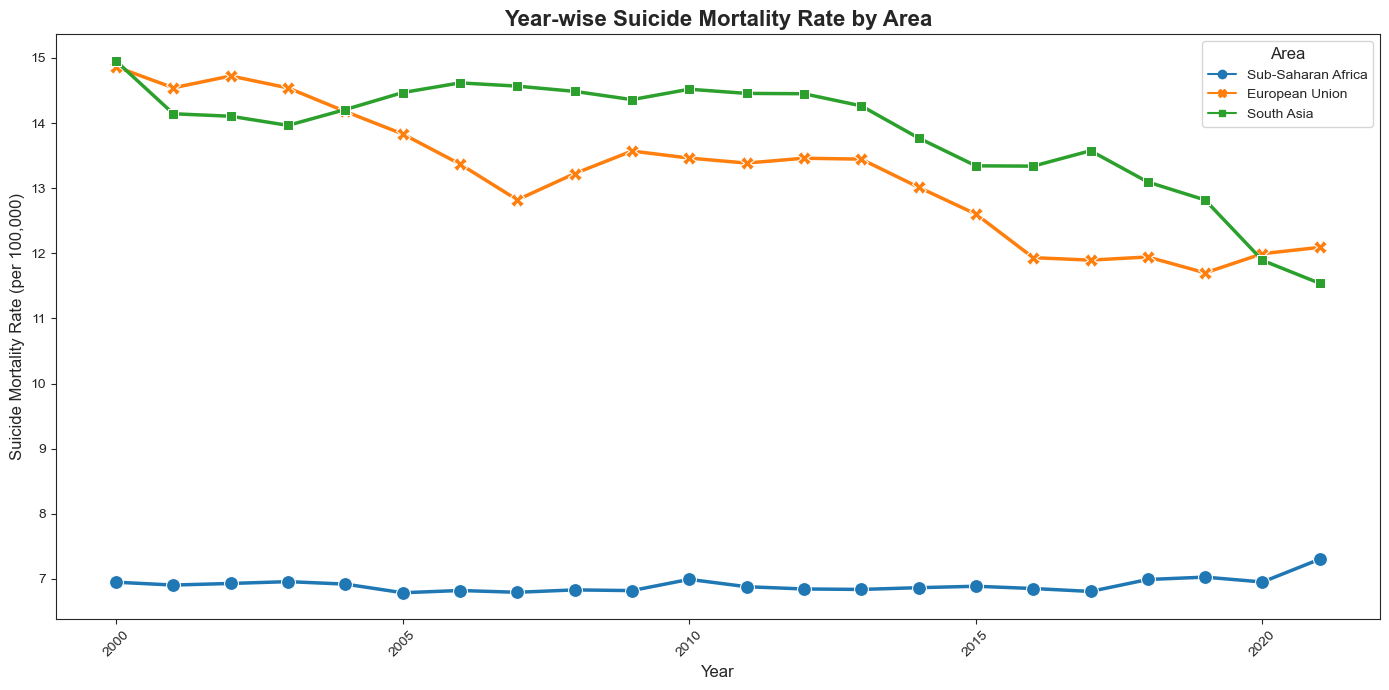

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style without grid
sns.set_style("ticks")
plt.figure(figsize=(14,7))

# Line plot
sns.lineplot(
    data=df_long,
    x='Year',
    y='Value',
    hue='Area',
    style='Area',       # different line styles per area
    markers=True,       # show markers
    dashes=False,       # solid lines
    palette="tab10",    # nice colors
    linewidth=2.5,
    markersize=10
)

# Remove grid lines
plt.grid(False)

# Titles and labels
plt.title("Year-wise Suicide Mortality Rate by Area", fontsize=16, fontweight='bold')
plt.ylabel("Suicide Mortality Rate (per 100,000)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(fontsize=10)
plt.legend(title='Area', fontsize=10, title_fontsize=12)
plt.tight_layout()

plt.show()


In [13]:
# Create a pivot table: rows = Year, columns = Area, values = Value
table = df_long.pivot_table(
    index='Year',        # rows
    columns='Area',      # columns
    values='Value',      # values to fill
    aggfunc='mean'       # in case there are duplicates
)

# round to 2 decimals for better readability
table = table.round(2)

# Reset index to make Year a column
table = table.reset_index()

# Preview the table
print(table)


Area  Year  European Union  South Asia  Sub-Saharan Africa
0     2000           14.86       14.95                6.95
1     2001           14.54       14.14                6.91
2     2002           14.72       14.10                6.93
3     2003           14.54       13.96                6.96
4     2004           14.18       14.21                6.92
5     2005           13.83       14.47                6.79
6     2006           13.37       14.62                6.82
7     2007           12.82       14.57                6.80
8     2008           13.22       14.49                6.83
9     2009           13.57       14.36                6.82
10    2010           13.46       14.52                6.99
11    2011           13.39       14.46                6.88
12    2012           13.46       14.45                6.85
13    2013           13.45       14.26                6.84
14    2014           13.01       13.77                6.87
15    2015           12.60       13.34                6.